In [ ]:
import pandas as pd

# 1. S-Boxes
SBOX_ORIGINAL = [0xC, 0x5, 0x6, 0xB,
                 0x9, 0x0, 0xA, 0xD,
                 0x3, 0xE, 0xF, 0x8,
                 0x4, 0x7, 0x1, 0x2]

SBOX_MOD1 = SBOX_ORIGINAL.copy()
SBOX_MOD1[0] = SBOX_MOD1[1]

SBOX_MOD2 = SBOX_ORIGINAL.copy()
SBOX_MOD2[2] = SBOX_MOD2[2] + SBOX_MOD2[3]
SBOX_MOD2[3] = SBOX_MOD2[2] - SBOX_MOD2[3]
SBOX_MOD2[2] = SBOX_MOD2[2] - SBOX_MOD2[3]

# 2. Permutation Layer (P-box)
PBOX = [0, 16, 32, 48, 1, 17, 33, 49,
        2, 18, 34, 50, 3, 19, 35, 51,
        4, 20, 36, 52, 5, 21, 37, 53,
        6, 22, 38, 54, 7, 23, 39, 55,
        8, 24, 40, 56, 9, 25, 41, 57,
        10, 26, 42, 58, 11, 27, 43, 59,
        12, 28, 44, 60, 13, 29, 45, 61,
        14, 30, 46, 62, 15, 31, 47, 63]

def sbox_layer(state, sbox):
    output = 0
    for i in range(16):  # 16 nibbles (4-bit blocks in 64-bit)
        nibble = (state >> (4 * i)) & 0xF
        output |= (sbox[nibble] << (4 * i))
    return output

def p_layer(state):
    output = 0
    for i in range(64):
        bit = (state >> i) & 1
        output |= (bit << PBOX[i])
    return output

def add_round_key(state, round_key):
    return state ^ round_key

# 3. Key Schedule for 80-bit Key
def generate_round_keys(master_key, rounds=32):
    round_keys = []
    key = master_key  # 80-bit

    for round_counter in range(1, rounds + 1):
        # Extract round key: top 64 bits of key
        round_keys.append((key >> 16) & 0xFFFFFFFFFFFFFFFF)

        # Key update:
        # 1. Rotate left 61 bits
        key = ((key << 61) | (key >> 19)) & ((1 << 80) - 1)

        # 2. S-box application to leftmost 4 bits
        sbox_input = (key >> 76) & 0xF
        sbox_output = SBOX_ORIGINAL[sbox_input]
        key = (key & ~(0xF << 76)) | (sbox_output << 76)

        # 3. XOR round counter with bits 19 to 15
        key ^= round_counter << 15

    return round_keys
def present_encrypt(plaintext, master_key, sbox, rounds=32):
    round_keys = generate_round_keys(master_key, rounds)
    state = plaintext

    for i in range(rounds - 1):
        state = add_round_key(state, round_keys[i])
        state = sbox_layer(state, sbox)
        state = p_layer(state)

    # Final round (no S-box/P-layer)
    state = add_round_key(state, round_keys[-1])
    return state

def int_to_bin_list(val, bits=64):
    return list(map(int, format(val, f'0{bits}b')))

def generate_dataset():
    data = []
    master_key = 0x00000000000000000000  # 80-bit key (all 0s)

    for i in range(2**17):  # 131072 plaintexts
        plaintext = i

        ct0 = present_encrypt(plaintext, master_key, SBOX_ORIGINAL)
        data.append(int_to_bin_list(ct0) + [0])

        ct1 = present_encrypt(plaintext, master_key, SBOX_MOD1)
        data.append(int_to_bin_list(ct1) + [1])

        ct2 = present_encrypt(plaintext, master_key, SBOX_MOD2)
        data.append(int_to_bin_list(ct2) + [2])

        if i % 10000 == 0:
            print(f"Processed {i}/131072 plaintexts")

    df = pd.DataFrame(data)
    df.to_csv("present_dataset.csv", index=False, header=False)
    print("Dataset saved as 'present_dataset.csv'")
generate_dataset()
print("")


Processed 0/131072 plaintexts
Processed 10000/131072 plaintexts
Processed 20000/131072 plaintexts
Processed 30000/131072 plaintexts
Processed 40000/131072 plaintexts
Processed 50000/131072 plaintexts
Processed 60000/131072 plaintexts
Processed 70000/131072 plaintexts
Processed 80000/131072 plaintexts
Processed 90000/131072 plaintexts
Processed 100000/131072 plaintexts
Processed 110000/131072 plaintexts
Processed 120000/131072 plaintexts
Processed 130000/131072 plaintexts
Dataset saved as 'present_dataset.csv'



In [ ]:
# S-Boxes Verification
SBOX_ORIGINAL = [0xC, 0x5, 0x6, 0xB,
                 0x9, 0x0, 0xA, 0xD,
                 0x3, 0xE, 0xF, 0x8,
                 0x4, 0x7, 0x1, 0x2]
SBOX_MOD1 = SBOX_ORIGINAL.copy()
SBOX_MOD1[0] = SBOX_MOD1[1]

SBOX_MOD2 = SBOX_ORIGINAL.copy()
SBOX_MOD2[2] = SBOX_MOD2[2] + SBOX_MOD2[3]
SBOX_MOD2[3] = SBOX_MOD2[2] - SBOX_MOD2[3]
SBOX_MOD2[2] = SBOX_MOD2[2] - SBOX_MOD2[3]

print("The value of 0th and 1rst elemnt of SBOX is same in case 1:")
print("Value of 0th element of S-box:", SBOX_MOD1[0])
print("Value of 1rst element of Sbox:", SBOX_MOD1[1])
print("")
print("value of 2nd and 3rd elemnt BEFORE SWAPPING")
print("Value of 2nd element of S-box:", SBOX_ORIGINAL[2])
print("Value of 3rd element of Sbox:", SBOX_ORIGINAL[3])
print("")
print("The value of 2nd and 3rd elemnt is swapped correctly:")
print("Value of 2nd element of S-box:", SBOX_MOD2[2])
print("Value of 3rd element of Sbox:", SBOX_MOD2[3])

The value of 0th and 1rst elemnt of SBOX is same in case 1:
Value of 0th element of S-box: 5
Value of 1rst element of Sbox: 5

value of 2nd and 3rd elemnt BEFORE SWAPPING
Value of 2nd element of S-box: 6
Value of 3rd element of Sbox: 11

The value of 2nd and 3rd elemnt is swapped correctly:
Value of 2nd element of S-box: 11
Value of 3rd element of Sbox: 6


In [ ]:
from google.colab import files
files.download('present_dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Step 1: Load CSV
df = pd.read_csv("present_dataset.csv", header=None)

# Step 2: Split into X, y (and force integer dtype)
X = df.iloc[:, :-1].astype(int).values
y = df.iloc[:, -1].astype(int).values

# Step 3: One-hot encode y
y_encoded = to_categorical(y, num_classes=3)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
rows_to_check = [1000, 1001, 1002]

for row_index in rows_to_check:
    print(f"\n🔍 Verifying row {row_index} from CSV")

    # Step 1: Get the bits and label from CSV
    csv_bits = df.iloc[row_index, :-1].tolist()
    csv_label = df.iloc[row_index, -1]
    csv_bits_array = np.array(csv_bits, dtype=X_train.dtype)

    # Step 2: Search in training and test sets
    matches_train = np.where((X_train == csv_bits_array).all(axis=1))[0]
    matches_test  = np.where((X_test == csv_bits_array).all(axis=1))[0]

    # Step 3: Print results
    print("CSV Bits  :", csv_bits)
    print("CSV Label :", csv_label)

    if matches_train.size > 0:
        idx = matches_train[0]
        print("Found in TRAINING set")
        print("Model Bits :", X_train[idx].tolist())
        print("Label      :", y_train[idx].tolist())
    elif matches_test.size > 0:
        idx = matches_test[0]
        print("Found in TEST set")
        print("Model Bits :", X_test[idx].tolist())
        print("Label      :", y_test[idx].tolist())
    else:
        print("Row NOT FOUND — Possible dtype mismatch or float issue")



🔍 Verifying row 1000 from CSV
CSV Bits  : [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0]
CSV Label : 1
Found in TRAINING set
Model Bits : [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0]
Label      : [0.0, 1.0, 0.0]

🔍 Verifying row 1001 from CSV
CSV Bits  : [1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
CSV Label : 2
Found in TRAINING set
Model Bits : [1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
Label      : [0

In [ ]:
X_train.shape

(314572, 64)

In [ ]:
y_train.shape

(314572, 3)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,163 (235.01 KB)

 Trainable params: 60,163 (235.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.5564 - loss: 0.7366 - val_accuracy: 0.6638 - val_loss: 0.4690
Epoch 2/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.6651 - loss: 0.4712 - val_accuracy: 0.6645 - val_loss: 0.4660
Epoch 3/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.6673 - loss: 0.4647 - val_accuracy: 0.6683 - val_loss: 0.4633
Epoch 4/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.6651 - loss: 0.4640 - val_accuracy: 0.6658 - val_loss: 0.4628
Epoch 5/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.6660 - loss: 0.4653 - val_accuracy: 0.6680 - val_loss: 0.4635
0 reshape_1 <class 'keras.src.layers.reshaping.reshape.Reshape'>
1 conv2d_2 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
2 max_pooling2d_2 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
3 conv2d_3 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
4 max_pooling2d_3 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'

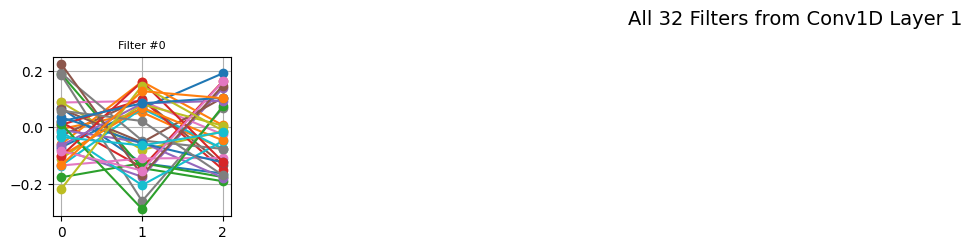

2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6659 - loss: 0.4644
 Test Accuracy: 0.6661


In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential([
    # Input layer: reshape 64 bits to 8x8
    layers.Reshape((8, 8, 1), input_shape=(64,)),

    # 1st Conv block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # 2nd Conv block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten layer (your request)
    layers.Flatten(),

    # Fully connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    # Output layer
    layers.Dense(3, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)
# Step 1: Confirm the layer index
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

# Step 2: Replace 1 with actual Conv1D layer index
filters, biases = model.layers[1].get_weights()

# Step 3: Plot
import matplotlib.pyplot as plt
num_filters = filters.shape[2]
plt.figure(figsize=(16, 8))
for i in range(num_filters):
    plt.subplot(4, 8, i + 1)
    plt.plot(filters[:, 0, i], marker='o')
    plt.title(f"Filter #{i}", fontsize=8)
    plt.xticks([0, 1, 2])
    plt.grid(True)
    plt.tight_layout()
plt.suptitle("All 32 Filters from Conv1D Layer 1", fontsize=14, y=1.02)
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f" Test Accuracy: {test_acc:.4f}")


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predict probabilities
predictions = model.predict(X_test)

# Convert predictions and labels to class numbers
true_classes = np.argmax(y_test, axis=1)          # From one-hot to class index
predicted_classes = np.argmax(predictions, axis=1)  # Get predicted class with highest probability

# Print Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))

# Classification Report (precision, recall, F1)
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))




2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Confusion Matrix:
[[24074  1679   347]
 [ 1402 24565    52]
 [24505  1713   307]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.92      0.63     26100
           1       0.88      0.94      0.91     26019
           2       0.43      0.01      0.02     26525

    accuracy                           0.62     78644
   macro avg       0.60      0.63      0.52     78644
weighted avg       0.60      0.62      0.52     78644



In [ ]:
# ANN model
X_train, X_test, y_train, y_test = train_test_split(Xa, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(314572, 64)

In [ ]:
y.shape

(393216, 3)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

In [ ]:
model2=Sequential()

In [ ]:
model2.add(Input(shape=(64,)))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32,activation='relu'))
model2.add(Dense(3,activation='softmax'))

In [ ]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model2.summary()

history2 = model2.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

test_loss, test_acc = model2.evaluate(X_test, y_test)
print(f" Test Accuracy: {test_acc:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,339 (24.76 KB)

 Trainable params: 6,339 (24.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5351 - loss: 0.8497 - val_accuracy: 0.6593 - val_loss: 0.5001
Epoch 2/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6667 - loss: 0.4911 - val_accuracy: 0.6657 - val_loss: 0.4790
Epoch 3/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6686 - loss: 0.4742 - val_accuracy: 0.6652 - val_loss: 0.4725
Epoch 4/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6681 - loss: 0.4681 - val_accuracy: 0.6622 - val_loss: 0.4743
Epoch 5/5
984/984 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6726 - loss: 0.4650 - val_accuracy: 0.6663 - val_loss: 0.4685
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6656 - loss: 0.4684
 Test Accuracy: 0.6631


In [ ]:

# Predict probabilities
predictions = model2.predict(X_test)

# Convert predictions and labels to class numbers
true_classes = np.argmax(y_test, axis=1)          # From one-hot to class index
predicted_classes = np.argmax(predictions, axis=1)  # Get predicted class with highest probability

# Print Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))

# Classification Report (precision, recall, F1)
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))

#  Print a few actual vs predicted
print("\nSample Predictions (Actual vs Predicted):")
for i in range(10):
    print(f"Sample {i}: Actual = {y_true[i]}, Predicted = {y_pred[i]}")

2458/2458 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Confusion Matrix:
[[12183    78 13839]
 [    0 26019     0]
 [12501    76 13948]]

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.47      0.48     26100
           1       0.99      1.00      1.00     26019
           2       0.50      0.53      0.51     26525

    accuracy                           0.66     78644
   macro avg       0.66      0.66      0.66     78644
weighted avg       0.66      0.66      0.66     78644

